In [ ]:
#Step 1 - Setup

!pip install pingouin -q #provides proper effect sizes

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
VERSION_ORDER = ["static", "adaptive"] #keep this order for consistency


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 4.0 MB/s eta 0:00:00


In [ ]:
#Step 2 - Get data

USE_DRIVE = True #False = upload-a-zip option instead

if USE_DRIVE:
  from google.colab import drive
  drive.mount('/content/drive')
  DATA_DIR = Path('/content/drive/MyDrive/DigitalMuseum/csv')
else:
  from google.colab import files
  import zipfile
  print("select the zipped csv export folder (e.g. full_study_csv.zip)")
  uploaded = files.upload()
  zip_name = next(iter(uploaded))
  with zipfile.ZipFile(zip_name) as z:
    z.extractall('/content/full_study_csv')
  DATA_DIR = Path('/content/full_study_csv')

print("looking in:", DATA_DIR)
print(sorted(p.name for p in DATA_DIR.glob('*.csv')))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
looking in: /content/drive/MyDrive/DigitalMuseum/csv
['adaptive_event.csv', 'adaptive_rule.csv', 'adaptive_suggestion.csv', 'artefact.csv', 'event_log.csv', 'participant.csv', 'questionnaire_item.csv', 'questionnaire_response.csv', 'session_completeness_summary.csv', 'session_log.csv', 'study_condition.csv', 'subtheme.csv', 'theme.csv', 'timeout.csv']


In [ ]:
#Step 3 - Load all tables

session_log = pd.read_csv(DATA_DIR / "session_log.csv", parse_dates=["session_start","session_end"])
participant = pd.read_csv(DATA_DIR / "participant.csv")
study_condition = pd.read_csv(DATA_DIR / "study_condition.csv")
theme = pd.read_csv(DATA_DIR / "theme.csv")
subtheme = pd.read_csv(DATA_DIR / "subtheme.csv")
artefact = pd.read_csv(DATA_DIR / "artefact.csv")
event_log = pd.read_csv(DATA_DIR / "event_log.csv", parse_dates=["timestamp"])
timeout = pd.read_csv(DATA_DIR / "timeout.csv", parse_dates=["timeout_timestamp"])
adaptive_rule = pd.read_csv(DATA_DIR / "adaptive_rule.csv")
adaptive_event = pd.read_csv(DATA_DIR / "adaptive_event.csv", parse_dates=["trigger_timestamp"])
adaptive_suggestion = pd.read_csv(DATA_DIR / "adaptive_suggestion.csv", parse_dates=["suggestion_timestamp"])
questionnaire_item = pd.read_csv(DATA_DIR / "questionnaire_item.csv")
questionnaire_response = pd.read_csv(DATA_DIR / "questionnaire_response.csv", parse_dates=["response_timestamp"])
completeness = pd.read_csv(DATA_DIR / "session_completeness_summary.csv", parse_dates=["session_start","session_end"])

print("Rows loaded:")
for name, df in [("session_log", session_log), ("event_log", event_log), ("timeout", timeout),
                  ("adaptive_event", adaptive_event), ("adaptive_suggestion", adaptive_suggestion),
                  ("questionnaire_response", questionnaire_response)]:
  print(f"{name}: {len(df)}")


Rows loaded:
session_log: 30
event_log: 8928
timeout: 62
adaptive_event: 3590
adaptive_suggestion: 2748
questionnaire_response: 362


In [ ]:
#Step 4 - Validate & clean raw data
#full-row and PK duplicates
#nulls in columns that should never be empty
#implausable values
#referential integrity

def validate_data():
  issues = {}

  #duplicates
  dup_rows = {name: df.duplicated().sum() for name, df in [
      ("session_log", session_log), ("event_log", event_log), ("timeout", timeout),
      ("adaptive_event", adaptive_event), ("adaptive_suggestion", adaptive_suggestion),
      ("questionnaire_response", questionnaire_response)
  ] if df.duplicated().sum() > 0}
  issues["duplicate full rows"] = dup_rows

  dup_pks = {}
  if event_log["event_id"].duplicated().sum():
    dup_pks["event_log.event_id"] = event_log["event_id"].duplicated().sum()
  if questionnaire_response["response_id"].duplicated().sum():
    dup_pks["questionnaire_response.response_id"] = questionnaire_response["response_id"].duplicated().sum()
  dup_item = questionnaire_response.duplicated(subset=["session_id", "item_id"]).sum()
  if dup_item:
    dup_pks["questionnaire_response (session_id.item_id)"] = dup_item
  issues["duplicate keys"] = dup_pks

  #nulls in columns that should always be populated
  null_counts = event_log[["timestamp", "event_type", "session_id"]].isna().sum()
  issues["event_log nulls"] = null_counts[null_counts > 0].to_dict()

  #implausible values
  implausible = {}
  bad_session_span = (session_log["session_end"] <= session_log["session_start"]).sum()
  if bad_session_span:
      implausible["sessions with end <= start"] = bad_session_span
  neg_dwell = (event_log["dwell_duration"] < 0).sum()
  if neg_dwell:
      implausible["negative dwell duration"] = neg_dwell
  zero_dwell = (event_log["dwell_duration"] == 0).sum()
  if zero_dwell:
      implausible["dwell duration == 0 (kept, not dropped)"] = zero_dwell

  likert_ids = questionnaire_item.loc[questionnaire_item["item_type"] == "likert", "item_id"]
  lik = questionnaire_response[questionnaire_response["item_id"].isin(likert_ids)].copy()
  lik["response_value"] = pd.to_numeric(lik["response_value"], errors="coerce")
  out_of_range = ((lik["response_value"] < 1) | (lik["response_value"] > 5) | lik["response_value"].isna()).sum()
  if out_of_range:
      implausible["likert responses outside 1-5 (or non-numeric)"] = out_of_range

  bad_codes = participant[~participant["participant_code"].str.match(r"^ppt([1-9]|[12][0-9]|30)$")]
  if len(bad_codes):
    implausible["participant_code not matching pptN (1-30)"] = bad_codes["participant_code"].tolist()
  issues["implausible values"] = implausible

  #referential integrity
  ref = {}
  bad_artefacts = set(event_log["artefact_id"].dropna().unique()) - set(artefact["artefact_id"].unique())
  if bad_artefacts:
    ref["event_log.artefact_id not in artefact.csv"] = bad_artefacts
  bad_sessions = set(event_log["session_id"].unique()) - set(session_log["session_id"].unique())
  if bad_sessions:
    ref["event_log.session_id not in session_log.csv"] = bad_sessions
  issues["referential integrity"] = ref

  return issues

validation_issues = validate_data()
for check, found in validation_issues.items():
  status = "OK - none found" if not found else found
  print(f"{check}: {status}")


duplicate full rows: OK - none found
duplicate keys: OK - none found
event_log nulls: OK - none found
implausible values: {'dwell duration == 0 (kept, not dropped)': np.int64(5)}
referential integrity: OK - none found


In [ ]:
#Step 5 - Build readable sessions table, apply completeness filter
#merges participant_code & condition_name

sessions = session_log.merge(participant[["participant_id", "participant_code"]], on="participant_id")
sessions = sessions.merge(study_condition[["condition_id", "condition_name"]], on="condition_id")

included_ids = completeness.loc[completeness["looks_complete"] == "yes", "session_id"]
n_before = len(sessions)
sessions = sessions [sessions["session_id"].isin(included_ids)].reset_index(drop=True)
print(f"Sessions: {n_before} total -> {len(sessions)} pass the completeness filter")

#readable artefact lookup (theme & subtheme names attached)
#artefact-level breakdowns
artefact_lookup = (
    artefact.merge(subtheme[["subtheme_id", "subtheme_name"]], on="subtheme_id")
    .merge(theme[["theme_id", "theme_name"]], on="theme_id")
)
sessions.head()


Sessions: 30 total -> 30 pass the completeness filter


,session_id,participant_id,condition_id,session_start,session_end,timeout_triggered_static,timeout_triggered_adaptive,error_flag,artefact_order,session_notes,participant_code,condition_name
0,53,52,1,2026-08-03 09:01:07,2026-08-03 09:22:37,1,1,0,"[13,54,9,46,2,59,23,32,17,26,38,44,12,55,6,50,...",NaN,ppt1,static_first
1,54,53,2,2026-08-03 09:53:30,2026-08-03 10:21:29,1,1,0,"[43,32,5,40,20,21,9,50,52,27,56,13,45,33,2,36,...",NaN,ppt2,adaptive_first
2,58,57,1,2026-08-06 08:10:33,2026-08-06 08:35:24,1,1,0,"[22,49,13,8,39,51,44,2,34,27,60,16,23,50,11,9,...",NaN,ppt3,static_first
3,59,58,2,2026-08-06 15:49:27,2026-08-06 16:13:10,1,1,0,"[5,53,7,15,32,45,16,38,22,28,58,48,4,54,9,14,3...",NaN,ppt4,adaptive_first
4,60,59,1,2026-08-06 16:14:43,2026-08-06 16:35:38,1,1,0,"[43,38,32,52,13,5,7,47,57,27,22,19,45,36,34,51...",NaN,ppt5,static_first


In [ ]:
#Step 6 - Split each session into static & adaptive halves
#each version has fixed 7-minute time limit
#phase_start is exactly 420s before the timeout

def build_phase_windows(sessions, timeout):
    """Returns one row per (session, version) with the phase's start/end timestamps."""

    PHASE_DURATION_S = 420

    to = timeout[timeout["session_id"].isin(sessions["session_id"])].copy()

    #handle duplicate timeout rows
    dupe_counts = to.groupby(["session_id", "version_name"]).size()
    dupes = dupe_counts[dupe_counts > 1]
    if len(dupes):
        print(f"[data quality] {len(dupes)} session/version pairs logged duplicate timeout rows - keeping the latest:")
        to = to.loc[to.groupby(["session_id", "version_name"])["timeout_timestamp"].idxmax()]

    #build output
    out = (
        to[["session_id", "version_name", "timeout_timestamp"]]
        .rename(columns={"version_name": "version", "timeout_timestamp": "phase_end"})
        .reset_index(drop=True)
    )
    out["phase_start"] = out["phase_end"] - pd.Timedelta(seconds=PHASE_DURATION_S)
    out["duration_s"] = (out["phase_end"] - out["phase_start"]).dt.total_seconds()

    #sort by completion order (earliest phase_start first)
    out = out.sort_values(["session_id", "phase_start"])
    out = out[["session_id", "version", "phase_start", "phase_end", "duration_s"]]
    return out

phase_windows = build_phase_windows(sessions, timeout)
assert phase_windows.groupby("session_id").size().eq(2).all(), "expected exactly 2 phases per session"
phase_windows.head()


[data quality] 2 session/version pairs logged duplicate timeout rows - keeping the latest:


,session_id,version,phase_start,phase_end,duration_s
1,53,static,2026-08-03 09:05:29,2026-08-03 09:12:29,420.0
0,53,adaptive,2026-08-03 09:12:29,2026-08-03 09:19:29,420.0
2,54,adaptive,2026-08-03 09:57:16,2026-08-03 10:04:16,420.0
3,54,static,2026-08-03 10:04:21,2026-08-03 10:11:21,420.0
5,58,static,2026-08-06 08:17:44,2026-08-06 08:24:44,420.0


In [ ]:

def tag_events_with_version(event_log, phase_windows):
  """Adds a 'version' column to event_log by checking which phase each event's timestamp falls into.
  Events outside any window (e.g. the final session_end, logged after both phases finish) are left as <NA>."""
  ev = event_log.copy()
  ev["version"] = pd.NA
  for sid, windows in phase_windows.groupby("session_id"):
    mask_sess = ev["session_id"] == sid
    for _, w in windows.iterrows():
      lower = ev["timestamp"] >= w["phase_start"]
      upper = ev["timestamp"] <= w["phase_end"]
      ev.loc[mask_sess & lower & upper, "version"] = w["version"]
  return ev

event_log_tagged = tag_events_with_version(
    event_log[event_log["session_id"].isin(sessions["session_id"])], phase_windows
    )

print("Event counts by type * version:")
display(event_log_tagged.groupby(["event_type", "version"],
        dropna=False).size().unstack(fill_value=0))

#Sanity check: panel_impression / panel_click / adaptive_trigger only ever happen during the adaptive task,
#so if the tagging logic is right, none of them should ever be tagged 'static'.
#This is a free correctness check on the phase-splitting logic above.
adaptive_only_types = {"panel_impression", "panel_click", "adaptive_trigger"}
mistagged = event_log_tagged[
    event_log_tagged["event_type"].isin(adaptive_only_types) & (event_log_tagged["version"] !="adaptive")
]
print(f"\nadaptive-only events mistagged as non-adaptive: {len(mistagged)} (should be 0)")

#regression check
#every timeout_redirect tagged with its version
untagged_timeouts = event_log_tagged[
    (event_log_tagged["event_type"] == "timeout_redirect") & event_log_tagged["version"].isna()
]
print(f"timeout_redirect events left untagged: {len(untagged_timeouts)} (should be 0)")



Event counts by type * version:


version,adaptive,static,NaN
event_type,,,
adaptive_trigger,687,0,0
click,636,664,0
dwell_end,618,648,0
dwell_start,637,662,0
navigation_depth,637,662,0
panel_click,155,0,0
panel_impression,2748,0,0
revisit,36,16,0
session_end,0,0,30



adaptive-only events mistagged as non-adaptive: 0 (should be 0)
timeout_redirect events left untagged: 0 (should be 0)


In [ ]:
#Step 7 - Behavioural metrics per participant * version
#builds one row per participant per version
#with core behavioural measures
#useful for statistical test & most plots

def summarise_behaviour(event_log_tagged, sessions):
  df = event_log_tagged.merge(sessions[["session_id", "participant_code", "condition_name"]], on="session_id")
  df = df.dropna(subset=["version"])

  clicks = df[df.event_type == "click"].groupby(["participant_code", "version"]).size().rename("n_clicks")
  dwell = (
      df[df.event_type == "dwell_end"]
      .groupby(["participant_code", "version"])["dwell_duration"]
      .agg(mean_dwell_s="mean", total_dwell_s="sum", n_dwells="count")
  )
  navdepth = (
      df[df.event_type == "navigation_depth"]
      .groupby(["participant_code", "version"])["navigation_depth"].max()
      .rename("max_navigation_depth")
  )
  revisits = df[df.event_type == "revisit"].groupby(["participant_code", "version"]).size().rename("n_revisits")
  unique_artefacts = (
      df[df.event_type == "click"]
      .groupby(["participant_code", "version"])["artefact_id"].nunique()
      .rename("n_unique_artefacts_viewed")
  )

  out = pd.concat([clicks, dwell, navdepth, revisits, unique_artefacts], axis=1).reset_index()
  out["n_revisits"] = out["n_revisits"].fillna(0)
  return out

behaviour_summary = summarise_behaviour(event_log_tagged, sessions)

pw = phase_windows.merge(sessions[["session_id", "participant_code"]], on="session_id")
behaviour_summary = behaviour_summary.merge(
    pw[["participant_code", "version", "duration_s"]].rename(columns={"duration_s": "time_on_task_s"}),
    on=["participant_code", "version"], how="left",
)

assert (behaviour_summary["time_on_task_s"] == 420).all(), "expected every phase to be exactly the fixed 420s time limit"
print("time_on_task_s is fixed at 420s for everyparticipant * version by design - kept as sanity check")

print("behaviour_summary:", behaviour_summary.shape, "(expect 60 rows = 30 participants * 2 versions)")
behaviour_summary.head()


time_on_task_s is fixed at 420s for everyparticipant * version by design - kept as sanity check
behaviour_summary: (60, 10) (expect 60 rows = 30 participants * 2 versions)


,participant_code,version,n_clicks,mean_dwell_s,total_dwell_s,n_dwells,max_navigation_depth,n_revisits,n_unique_artefacts_viewed,time_on_task_s
0,ppt1,adaptive,17,12.812500,205.0,16,17.0,1.0,16,420.0
1,ppt1,static,15,13.214286,185.0,14,15.0,0.0,15,420.0
2,ppt10,adaptive,21,12.000000,240.0,20,21.0,0.0,21,420.0
3,ppt10,static,20,10.050000,201.0,20,20.0,0.0,20,420.0
4,ppt11,adaptive,18,7.647059,130.0,17,18.0,0.0,18,420.0


In [ ]:
#Step 8 - Adaptive-only engagement metrics
#how often adaptive logic fired & how confident it was
#how many artefacts the panel suggested
#what fraction the participant actually clicked
#the model's average interest score

ae = adaptive_event.merge(sessions[["session_id", "participant_code"]], on="session_id")
mean_conf = ae.groupby("participant_code")["trigger_confidence"].mean().rename("mean_trigger_confidence")
n_triggers = ae.groupby("participant_code").size().rename("n_adaptive_triggers")

sugg = adaptive_suggestion.merge(sessions[["session_id", "participant_code"]], on="session_id")
suggestion_click_rate = sugg.groupby("participant_code")["clicked_flag"].mean().rename("suggestion_click_rate")
mean_interest_score = sugg.groupby("participant_code")["interest_score"].mean().rename("mean_interest_score")
n_suggestions = sugg.groupby("participant_code").size().rename("n_suggestions_shown")

panel_ev = event_log_tagged[event_log_tagged["event_type"].isin(["panel_impression", "panel_click"])].merge(
    sessions[["session_id", "participant_code"]], on="session_id"
)
panel_impressions = panel_ev[panel_ev.event_type ==
  "panel_impression"].groupby("participant_code").size().rename("n_panel_impressions")
panel_clicks = panel_ev[panel_ev.event_type ==
  "panel_click"].groupby("participant_code").size().rename("panel_clicks")

adaptive_summary = pd.concat(
    [n_triggers, mean_conf, n_suggestions, suggestion_click_rate, mean_interest_score, panel_impressions, panel_clicks],
    axis=1,
).reset_index().fillna(0)

adaptive_summary.head()


,participant_code,n_adaptive_triggers,mean_trigger_confidence,n_suggestions_shown,suggestion_click_rate,mean_interest_score,n_panel_impressions,panel_clicks
0,ppt1,164,1.857097,124,0.072581,1.857097,124,9.0
1,ppt10,92,2.113333,72,0.027778,2.113333,72,2.0
2,ppt11,105,2.149048,84,0.000000,2.149048,84,0.0
3,ppt12,121,1.672174,92,0.065217,1.672174,92,6.0
4,ppt13,85,0.856471,68,0.000000,0.856471,68,0.0


In [ ]:
#Step 9 - Questionnaire responses -> wide format
#pulls out each item's formal name from notes
#responses split 3 ways by item_type

def extract_formal_name(notes):
  m = re.search(r"Formal name:\s*([A-Za-z0-9_]+)", str(notes))
  return m.group(1) if m else None

questionnaire_item["formal_name"] = questionnaire_item["item_notes"].apply(extract_formal_name)
display(questionnaire_item[["item_id", "item_type", "formal_name"]])

qr = questionnaire_response.merge(sessions[["session_id", "participant_code"]], on="session_id")
qr = qr.merge(questionnaire_item[["item_id", "formal_name", "item_type"]], on="item_id")

qr_likert = qr[qr["item_type"] == "likert"].copy()
qr_likert["response_value"] = pd.to_numeric(qr_likert["response_value"], errors="raise")
wide_likert = qr_likert.pivot(index="participant_code", columns="formal_name", values="response_value")

wide_cat = qr[qr["item_type"] == "multiple_choice"].pivot(
    index="participant_code", columns="formal_name", values="response_value"
)

qualitative = qr[qr["item_type"] == "free_text"][["participant_code", "formal_name", "response_value"]].rename(
    columns={"response_value": "response_text"}
)
DIMENSIONS = ["relevance", "surprise", "freedom", "experience"] #4 paired Likert dimensions

wide_likert.head()


,item_id,item_type,formal_name
0,1,multiple_choice,order_completed_first
1,2,likert,static_relevance
2,3,likert,static_surprise
3,4,likert,static_freedom
4,5,likert,static_experience
5,6,free_text,static_comment
6,7,likert,adaptive_relevance
7,8,likert,adaptive_surprise
8,9,likert,adaptive_freedom
9,10,likert,adaptive_experience


formal_name,adaptive_experience,adaptive_freedom,adaptive_relevance,adaptive_surprise,static_experience,static_freedom,static_relevance,static_surprise
participant_code,,,,,,,,
ppt1,5,5,5,4,3,4,4,2
ppt10,5,5,5,5,5,4,4,4
ppt11,4,4,3,4,4,4,3,4
ppt12,4,3,5,4,3,4,2,3
ppt13,4,4,4,3,4,4,4,3


In [ ]:
#Step 10 - Descriptive statistics
#quick means/SDs before running any tests
#final small validity check
#catches self-report slip ups for questionnaire item 1

print("=== Questionnaire dimensions (1-5 Likert) ===")
desc_rows = []
for d in DIMENSIONS:
  for v in VERSION_ORDER:
    col = wide_likert[f"{v}_{d}"]
    desc_rows.append({"dimension": d, "version": v, "mean": col.mean(), "sd": col.std(), "n": col.count()})
display(pd.DataFrame(desc_rows).round(2))

print("\n=== Behavioural metrics ===")
display(behaviour_summary.drop(columns="participant_code").groupby("version").agg(["mean", "std"]).round(2))

print("\n=== Preference (item 12) ===")
display(wide_cat["preferred_version"].value_counts())

print("\n=== Order completed first (item 1) vs stated condition ===")
display(wide_cat["order_completed_first"].value_counts())

print("\n=== Actual (logged) vs self-reported order completed first ===")
order_check = sessions[["participant_code", "condition_name"]].copy()
order_check["actual_first"] = order_check["condition_name"].str.replace("_first", "", regex=False)
order_check = order_check.merge(wide_cat[["order_completed_first"]].reset_index(), on="participant_code")
order_check["stated_first"] = order_check["order_completed_first"].str.replace(" version", "", regex=False).str.lower()
order_check["match"] = order_check["actual_first"] == order_check["stated_first"]
display(order_check[["participant_code", "actual_first", "order_completed_first", "match"]])

n_mismatch = (~order_check["match"]).sum()
mismatched_ppts = order_check.loc[~order_check["match"], "participant_code"].tolist()
print(f"{n_mismatch} mismatch(es) out of {len(order_check)}: {mismatched_ppts}")


=== Questionnaire dimensions (1-5 Likert) ===


,dimension,version,mean,sd,n
0,relevance,static,3.07,0.78,30
1,relevance,adaptive,4.00,0.79,30
2,surprise,static,3.40,1.13,30
3,surprise,adaptive,3.63,1.07,30
4,freedom,static,4.00,1.02,30
5,freedom,adaptive,4.20,0.85,30
6,experience,static,4.07,0.64,30
7,experience,adaptive,4.47,0.51,30



=== Behavioural metrics ===


n_clicks       mean_dwell_s       total_dwell_s        n_dwells       max_navigation_depth       n_revisits        \
             mean   std         mean   std          mean    std     mean   std                 mean   std       mean   std   
version                                                                                                                      
adaptive    21.20  7.33         9.85  3.85        180.80  40.68     20.6  7.52                21.07  7.01       1.20  1.56   
static      22.13  8.46        10.85  3.49        212.27  37.39     21.6  8.46                22.07  8.46       0.53  1.33   

         n_unique_artefacts_viewed       time_on_task_s       
                              mean   std           mean  std  
version                                                       
adaptive                     19.97  6.48          420.0  0.0  
static                       21.60  7.54          420.0  0.0


=== Preference (item 12) ===


...


=== Order completed first (item 1) vs stated condition ===


,count
order_completed_first,
Adaptive version,16
Static version,14



=== Actual (logged) vs self-reported order completed first ===


,participant_code,actual_first,order_completed_first,match
0,ppt1,static,Static version,True
1,ppt2,adaptive,Adaptive version,True
2,ppt3,static,Adaptive version,False
3,ppt4,adaptive,Adaptive version,True
4,ppt5,static,Static version,True
5,ppt6,adaptive,Adaptive version,True
6,ppt7,static,Static version,True
7,ppt8,adaptive,Adaptive version,True
8,ppt9,static,Static version,True
9,ppt10,adaptive,Adaptive version,True


1 mismatch(es) out of 30: ['ppt3']


In [ ]:
#Step 11 - Paired tests: questionnaire dimensions
#static vs adaptive
#Wilcoxon signed rank safer
#normality checked to decide which test

def paired_compare(a, b, label):
  diff = (a - b).dropna()
  shapiro_p = stats.shapiro(diff).pvalue if len(diff) >= 3 else np.nan
  if shapiro_p >= 0.05:
    r = pg.ttest(a, b, paired=True)
    return {"measure": label, "n": len(diff), "mean_static": a.mean(), "mean_adaptive" : b.mean(),
            "test": "paired t-test", "statistic": r["T"].iloc[0], "p": r["p_val"].iloc[0],
            "effect_size": r["cohen_d"].iloc[0], "effect_label": "Cohen's d", "shapiro_p_on_diffs": shapiro_p}
  else:
    r = pg.wilcoxon(a, b)
    return {"measure": label, "n": len(diff), "mean_static": a.mean(), "mean_adaptive" : b.mean(),
            "test": "Wilcoxon signed-rank", "statistic": r["W_val"].iloc[0], "p": r["p_val"].iloc[0],
            "effect_size": r["RBC"].iloc[0], "effect_label": "rank-biserial r", "shapiro_p_on_diffs": shapiro_p}

questionnaire_results = pd.DataFrame([
    paired_compare(wide_likert[f"static_{d}"], wide_likert[f"adaptive_{d}"], d) for d in DIMENSIONS
    for d in DIMENSIONS
])
questionnaire_results.round(4)


,measure,n,mean_static,mean_adaptive,test,statistic,p,effect_size,effect_label,shapiro_p_on_diffs
0,relevance,30,3.0667,4.0000,Wilcoxon signed-rank,0.0,0.0002,-1.0000,rank-biserial r,0.0000
1,surprise,30,3.4000,3.6333,Wilcoxon signed-rank,44.0,0.3648,-0.2667,rank-biserial r,0.0029
2,freedom,30,4.0000,4.2000,Wilcoxon signed-rank,38.0,0.3643,-0.2762,rank-biserial r,0.0011
3,experience,30,4.0667,4.4667,Wilcoxon signed-rank,6.5,0.0031,-0.8571,rank-biserial r,0.0000
4,relevance,30,3.0667,4.0000,Wilcoxon signed-rank,0.0,0.0002,-1.0000,rank-biserial r,0.0000
5,surprise,30,3.4000,3.6333,Wilcoxon signed-rank,44.0,0.3648,-0.2667,rank-biserial r,0.0029
6,freedom,30,4.0000,4.2000,Wilcoxon signed-rank,38.0,0.3643,-0.2762,rank-biserial r,0.0011
7,experience,30,4.0667,4.4667,Wilcoxon signed-rank,6.5,0.0031,-0.8571,rank-biserial r,0.0000
8,relevance,30,3.0667,4.0000,Wilcoxon signed-rank,0.0,0.0002,-1.0000,rank-biserial r,0.0000
9,surprise,30,3.4000,3.6333,Wilcoxon signed-rank,44.0,0.3648,-0.2667,rank-biserial r,0.0029


In [ ]:
#Step 12 - Paired tests: behavioural metrics
#static vs adaptive
#same paired comparison logic

beh_wide = behaviour_summary.pivot(index="participant_code", columns="version")
BEH_METRICS = ["n_clicks", "mean_dwell_s", "total_dwell_s", "max_navigation_depth",
               "n_revisits", "n_unique_artefacts_viewed"]

behaviour_results = pd.DataFrame([
    paired_compare(beh_wide[(m, "static")], beh_wide[(m, "adaptive")], m) for m in BEH_METRICS
])
behaviour_results.round(4)


,measure,n,mean_static,mean_adaptive,test,statistic,p,effect_size,effect_label,shapiro_p_on_diffs
0,n_clicks,30,22.1333,21.2000,paired t-test,0.7812,0.4410,0.1180,Cohen's d,0.1879
1,mean_dwell_s,30,10.8495,9.8466,paired t-test,1.5569,0.1303,0.2732,Cohen's d,0.3607
2,total_dwell_s,30,212.2667,180.8000,paired t-test,3.6677,0.0010,0.8054,Cohen's d,0.8993
3,max_navigation_depth,30,22.0667,21.0667,Wilcoxon signed-rank,191.5000,0.8019,0.0567,rank-biserial r,0.0177
4,n_revisits,30,0.5333,1.2000,Wilcoxon signed-rank,34.5000,0.0064,-0.6714,rank-biserial r,0.0001
5,n_unique_artefacts_viewed,30,21.6000,19.9667,paired t-test,1.5273,0.1375,0.2323,Cohen's d,0.1744


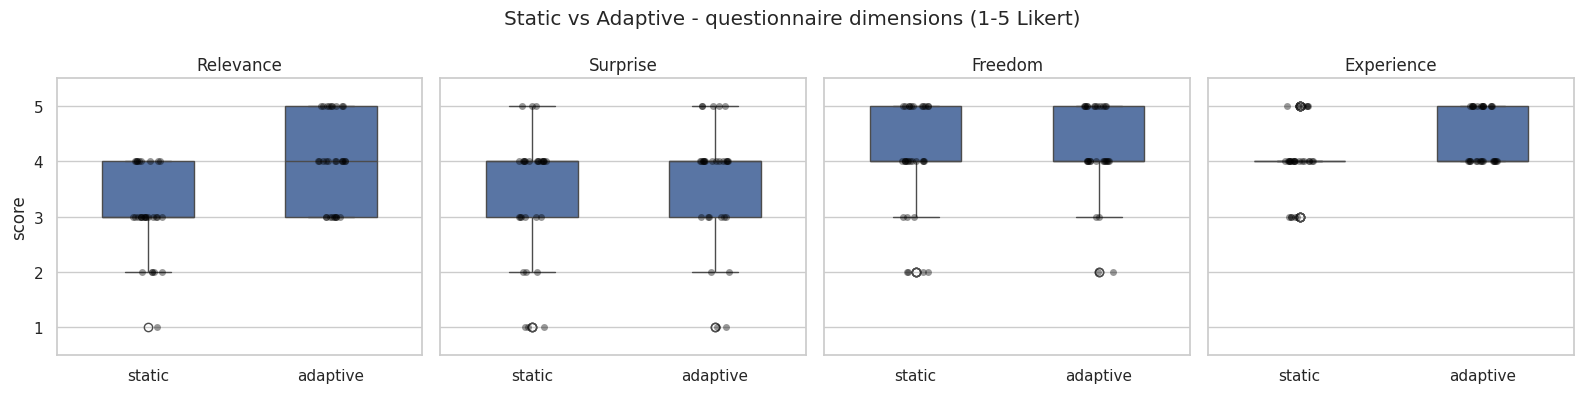

In [ ]:
#Step 13 - Visualise: questionnaire dimensions
#paired boxplots for each dimension

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, d in zip(axes, DIMENSIONS):
  plot_df = wide_likert[[f"static_{d}", f"adaptive_{d}"]].reset_index().melt(
      id_vars="participant_code", var_name="version", value_name="score"
  )
  plot_df["version"] = plot_df["version"].str.replace(f"_{d}", "", regex=False)
  sns.boxplot(data=plot_df, x="version", y="score", order=VERSION_ORDER, ax=ax, width=0.5)
  sns.stripplot(data=plot_df, x="version", y="score", order=VERSION_ORDER, ax=ax, color="black", alpha=0.4, jitter=0.08)
  ax.set_title(d.capitalize())
  ax.set_xlabel("")
  ax.set_ylim(0.5, 5.5)
fig.suptitle("Static vs Adaptive - questionnaire dimensions (1-5 Likert)")
fig.tight_layout()
plt.savefig("questionnaire_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()


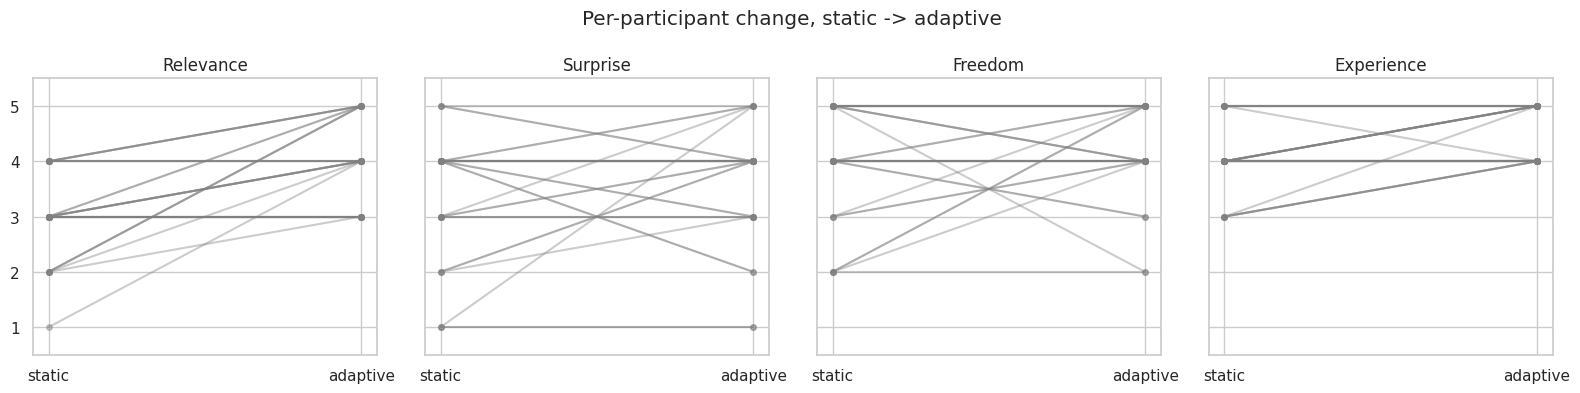

In [ ]:
#Step 14 - Visualise: within-subject change per participant
#slope plot drawing a line per participant
#looking for a shift across participants

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, d in zip(axes, DIMENSIONS):
  for _, row in wide_likert.iterrows():
    ax.plot([0, 1], [row[f"static_{d}"], row[f"adaptive_{d}"]], color="grey", alpha=0.4, marker="o", markersize=4)
  ax.set_xticks([0, 1])
  ax.set_xticklabels(VERSION_ORDER)
  ax.set_title(d.capitalize())
  ax.set_ylim(0.5, 5.5)
fig.suptitle("Per-participant change, static -> adaptive")
fig.tight_layout()
plt.savefig("questionnaire_slopes.png", dpi=150, bbox_inches="tight")
plt.show()


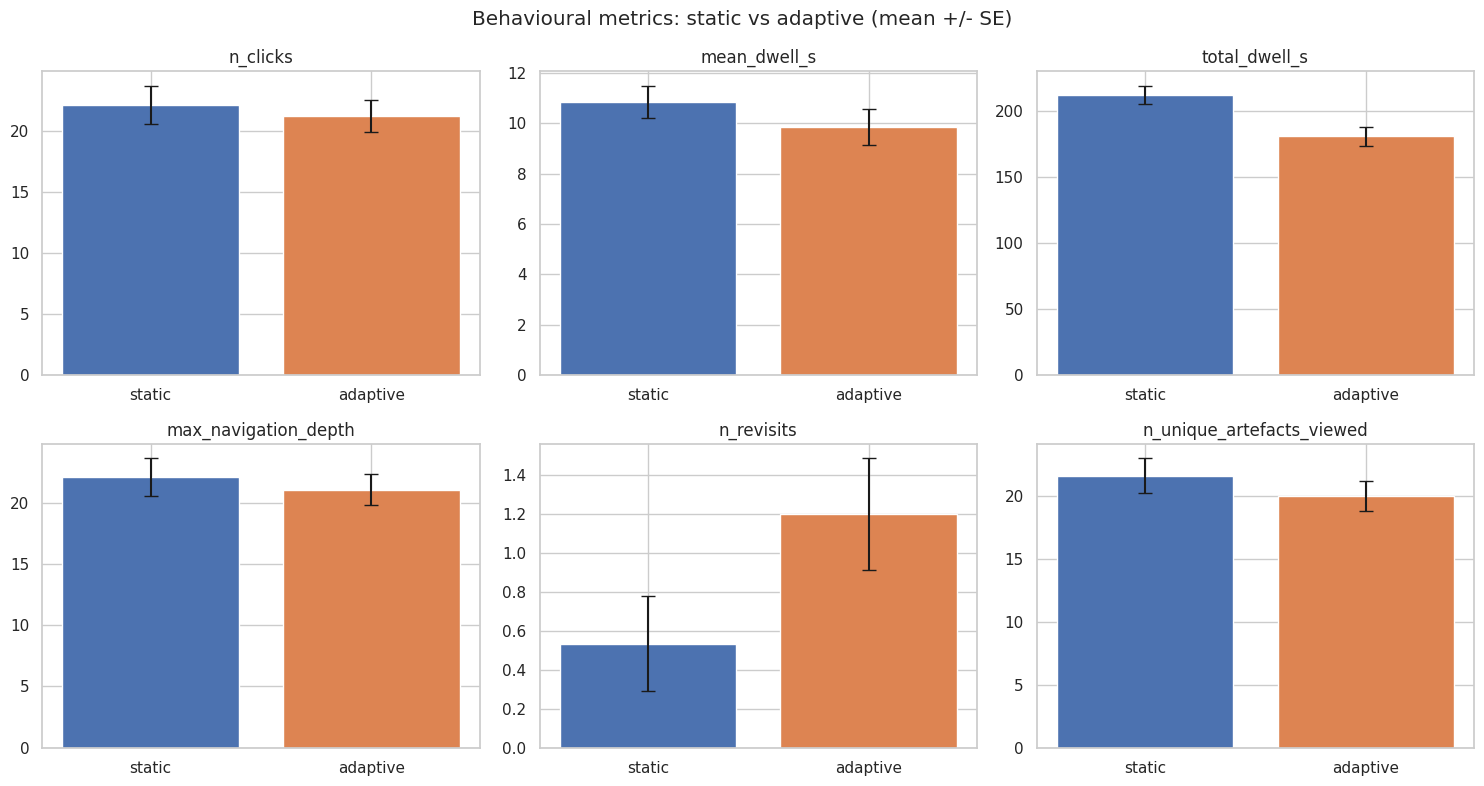

In [ ]:
#Step 15 - Visualise: behavioural metrics
#bar chart of the mean for each behavioural metric by version
#with standard error bars

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, m in zip(axes.flat, BEH_METRICS):
  means = behaviour_summary.groupby("version")[m].mean().reindex(VERSION_ORDER)
  sems = behaviour_summary.groupby("version")[m].sem().reindex(VERSION_ORDER)
  ax.bar(means.index, means.values, yerr=sems.values, capsize=5, color=["#4C72B0", "#DD8452"])
  ax.set_title(m)

fig.suptitle("Behavioural metrics: static vs adaptive (mean +/- SE)")
fig.tight_layout()
plt.savefig("behavioural_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


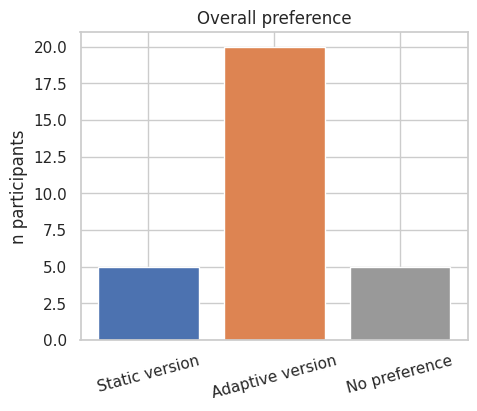

Rows = which version was actually completed first
columns = which version preferred:


preferred_version,Adaptive version,No preference,Static version
actual_first,,,
Adaptive version,12,3,0
Static version,8,2,5


In [ ]:
#Step 16 - Visualise: preference & order effects
#bar chart of stated overall preference
#cross-tab of first version & preferred version

fig, ax = plt.subplots(figsize=(5, 4))
order = ["Static version", "Adaptive version", "No preference"]
counts = wide_cat["preferred_version"].value_counts().reindex(order).fillna(0)
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452", "#999999"])
ax.set_title("Overall preference")
ax.set_ylabel("n participants")
plt.xticks(rotation=15)
plt.savefig("preference.png", dpi=150, bbox_inches="tight")
plt.show()

#system-logged 'did first' not self-reported
#corrects the known ppt3 mismatch
actual_first_labelled = (
    order_check.set_index("participant_code")["actual_first"].str.capitalize() + " version"
).reindex(wide_cat.index)

order_effect = pd.crosstab(actual_first_labelled, wide_cat["preferred_version"])
print("Rows = which version was actually completed first")
print("columns = which version preferred:")
display(order_effect)


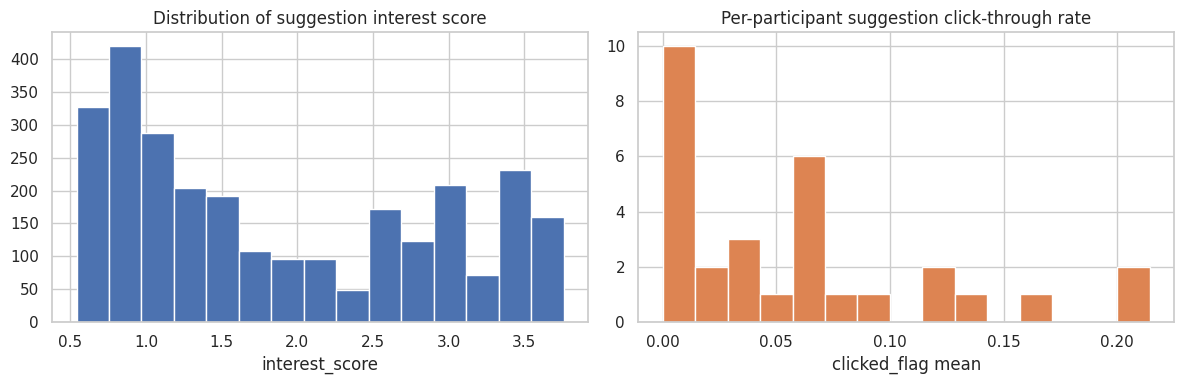

Overall suggestion click-through rate: 0.056
Mean trigger_condifence across all adaptive_event rows: 1.887


In [ ]:
#Step 17 - Visualise: adaptive suggestion effectiveness
#distribution of interest score across all suggestions shown
#per-participant suggestion click-through rate
#how often a suggestion was clicked

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sugg["interest_score"], bins=15, color="#4C72B0")
axes[0].set_title("Distribution of suggestion interest score")
axes[0].set_xlabel("interest_score")

axes[1].hist(adaptive_summary["suggestion_click_rate"], bins=15, color="#DD8452")
axes[1].set_title("Per-participant suggestion click-through rate")
axes[1].set_xlabel("clicked_flag mean")

fig.tight_layout()
plt.savefig("adaptive_effectiveness.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Overall suggestion click-through rate: {sugg['clicked_flag'].mean():.3f}")
print(f"Mean trigger_condifence across all adaptive_event rows: {adaptive_event['trigger_confidence'].mean():.3f}")


Excluded participant_id(s): [52, 53]
Excluded session_id(s): [53, 54]
sugg: 2748 -> 2404 rows after exclusion
adaptive_event: 3590 -> 3130 rows after exclusion
adaptive_summary: 30 -> 28 rows after exclusion


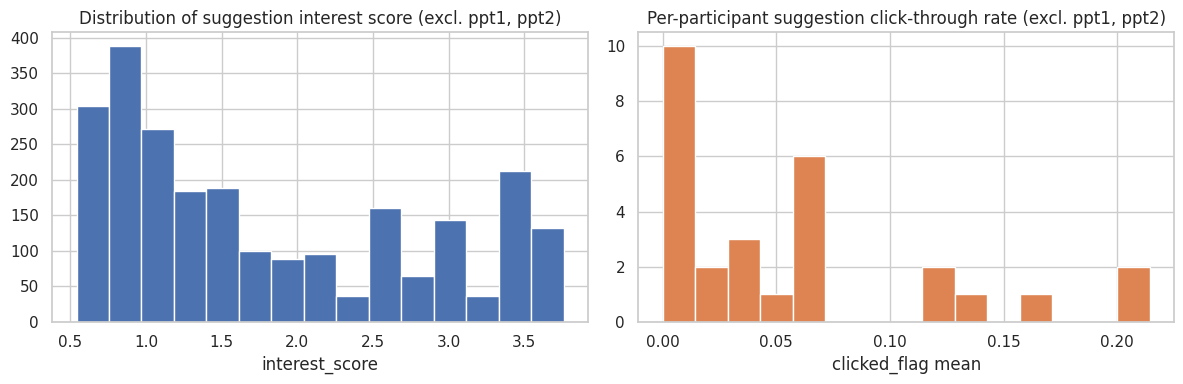

Overall suggestion click-through rate (excl. ppt1, ppt2): 0.052
Mean trigger_confidence across all adaptive_event rows (excl. ppt1, ppt2): 1.810


In [ ]:
#Exclude ppt1 and ppt2
#took part before serendipity rate limit was set

EXCLUDE_CODES = ["ppt1", "ppt2"]

excluded_participant_ids = participant.loc[
    participant["participant_code"].isin(EXCLUDE_CODES), "participant_id"
].tolist()
print("Excluded participant_id(s):", excluded_participant_ids)  #expect [52, 53]

excluded_session_ids = session_log.loc[
    session_log["participant_id"].isin(excluded_participant_ids), "session_id"
].tolist()
print("Excluded session_id(s):", excluded_session_ids)  #expect [53, 54]

#adaptive_suggestion and adaptive_event only carry session_id, not participant_id
#so exclusion has to go via session_id
sugg_excl = sugg[~sugg["session_id"].isin(excluded_session_ids)]
adaptive_event_excl = adaptive_event[~adaptive_event["session_id"].isin(excluded_session_ids)]

print(f"sugg: {len(sugg)} -> {len(sugg_excl)} rows after exclusion")
print(f"adaptive_event: {len(adaptive_event)} -> {len(adaptive_event_excl)} rows after exclusion")

#adaptive_summary is per-participant
#filter on whichever identifier it actually carries
if "participant_id" in adaptive_summary.columns:
    adaptive_summary_excl = adaptive_summary[~adaptive_summary["participant_id"].isin(excluded_participant_ids)]
elif "participant_code" in adaptive_summary.columns:
    adaptive_summary_excl = adaptive_summary[~adaptive_summary["participant_code"].isin(EXCLUDE_CODES)]
elif adaptive_summary.index.name == "participant_id":
    adaptive_summary_excl = adaptive_summary[~adaptive_summary.index.isin(excluded_participant_ids)]
else:
    raise ValueError("Couldn't find participant_id/participant_code in adaptive_summary - check its columns/index")

print(f"adaptive_summary: {len(adaptive_summary)} -> {len(adaptive_summary_excl)} rows after exclusion")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sugg_excl["interest_score"], bins=15, color="#4C72B0")
axes[0].set_title("Distribution of suggestion interest score (excl. ppt1, ppt2)")
axes[0].set_xlabel("interest_score")

axes[1].hist(adaptive_summary_excl["suggestion_click_rate"], bins=15, color="#DD8452")
axes[1].set_title("Per-participant suggestion click-through rate (excl. ppt1, ppt2)")
axes[1].set_xlabel("clicked_flag mean")

fig.tight_layout()
plt.savefig("adaptive_effectiveness_excl_ppt1_ppt2.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Overall suggestion click-through rate (excl. ppt1, ppt2): {sugg_excl['clicked_flag'].mean():.3f}")
print(f"Mean trigger_confidence across all adaptive_event rows (excl. ppt1, ppt2): {adaptive_event_excl['trigger_confidence'].mean():.3f}")

In [ ]:
#Step 18 - Bring in thematic coding

CODING_XLSX = Path('/content/drive/MyDrive/DigitalMuseum/Full Study Data.xlsx')

#skiprows=4 skips the title + instruction rows above the real header row
#stops pandas silently blanking out genuine text answers like n/a
coded = pd.read_excel(
    CODING_XLSX, sheet_name="qualitative_coding", skiprows=4,
    keep_default_na=False, na_values=[""],
)

#genuinely empty cell still comes back as NaN
#every check compare response text directly
#without handling NaN
coded["response"] = coded["response"].fillna("")
coded = coded[(coded["code"] != "") & (coded["theme"] != "")] #keep only coded rows

print(f"{len(coded)} coded extracts across {coded['theme'].nunique()} themes")
coded.head()


62 coded extracts across 6 themes


,participant_code,item,item_text,preferred_version,response,code,theme,notes
0,ppt2,static_comment,Is there anything you would like to share abou...,Adaptive version,The static version seems to be well suited to ...,systematic browsing; manual discovery beyond s...,Self-Directed Exploration & Autonomy,Highlights that manual scrolling revealed arte...
1,ppt3,static_comment,Is there anything you would like to share abou...,Adaptive version,I explored based on mine and my son's interests.,family-driven exploration; interest-led browsing,Self-Directed Exploration & Autonomy,"Shows multi‑user influence (parent + child), r..."
2,ppt6,static_comment,Is there anything you would like to share abou...,Adaptive version,In comparison too the adaptive version navigat...,navigation friction,Exploration Constraints & Repetition,Brief but clear navigation complaint.
3,ppt8,static_comment,Is there anything you would like to share abou...,Adaptive version,it felt like I had to view all the artefacts i...,pressure to view everything; mismatch with per...,Exploration Constraints & Repetition,Strong sense of obligation; useful for discuss...
4,ppt10,static_comment,Is there anything you would like to share abou...,Adaptive version,layout was very clear,clear layout,"Navigation Clarity, Ease & Efficiency",Good quote for illustrating static layout stre...


In [ ]:
#Step 19 - Data check
#row should have both theme and response text
#checks if a cell got cleared by accident while coding
#checks & deletes rows with no response placeholders

missing_text = coded[coded["response"] == ""]
if len(missing_text):
  print("Rows with a code/theme but no genuinely empty response cell - double check these")
  print("weren't cleared by accidient when filling in the coding columns:")
  display(missing_text[["participant_code", "item", "code", "theme"]])
else:
  print("No genuinely empty response cells.")

#no response placeholders excluded from coded extracts
NO_RESPONSE_MARKERS = ["n/a"]
is_no_response = coded["response"].str.lower().str.contains(
    "|".join(NO_RESPONSE_MARKERS), regex=True, na=False
)
removed = coded[is_no_response]
if len(removed):
  print(f"\nRemoving {len(removed)} row(s) - participant indicated they had no response:")
  display(removed[["participant_code", "item", "response", "code", "theme"]])
  coded = coded[~is_no_response]
else:
  print("\nNo 'no response' placeholders found.")

print(f"\n{len(coded)} coded extracts remain across {coded['theme'].nunique()} themes")


No genuinely empty response cells.

Removing 1 row(s) - participant indicated they had no response:


,participant_code,item,response,code,theme
54,ppt6,final_comments,n/a,no additional feedback,Comparative Evaluation & Balanced Views



61 coded extracts remain across 6 themes


,n_extracts
theme,
"Relevance, Personalisation & Interest Alignment",15
"Navigation Clarity, Ease & Efficiency",11
"Discovery, Learning & Serendipity",10
Self-Directed Exploration & Autonomy,9
Comparative Evaluation & Balanced Views,9
Exploration Constraints & Repetition,7


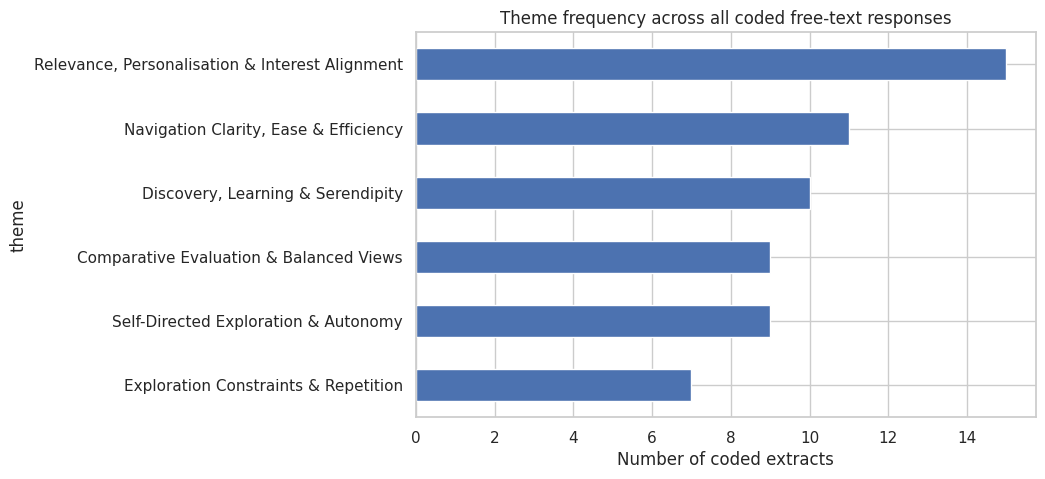

In [ ]:
#Step 20 - Theme frequency
#how many coded extracts fall under each theme

theme_counts = coded["theme"].value_counts().rename("n_extracts")
display(theme_counts.to_frame())

fig, ax = plt.subplots(figsize=(8, 5))
theme_counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of coded extracts")
ax.set_title("Theme frequency across all coded free-text responses")
plt.savefig("theme_frequency.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
#Step 21 - Triangualtion against quantitative data
#which themes show up under which questionnaire item
#which themes cluster around which preferred version

theme_by_item = pd.crosstab(coded["theme"], coded["item"])
print("Theme * questionnaire item:")
display(theme_by_item)

theme_by_preference = pd.crosstab(coded["theme"], coded["preferred_version"])
print("\nTheme * stated overall preference:")
display(theme_by_preference)


Theme * questionnaire item:


item,adaptive_comment,final_comments,preference_reason,static_comment
theme,,,,
Comparative Evaluation & Balanced Views,1,4,4,0
"Discovery, Learning & Serendipity",3,4,1,2
Exploration Constraints & Repetition,3,0,0,4
"Navigation Clarity, Ease & Efficiency",2,1,5,3
"Relevance, Personalisation & Interest Alignment",4,0,11,0
Self-Directed Exploration & Autonomy,0,0,3,6



Theme * stated overall preference:


preferred_version,Adaptive version,No preference,Static version
theme,,,
Comparative Evaluation & Balanced Views,3,5,1
"Discovery, Learning & Serendipity",6,4,0
Exploration Constraints & Repetition,5,0,2
"Navigation Clarity, Ease & Efficiency",10,0,1
"Relevance, Personalisation & Interest Alignment",15,0,0
Self-Directed Exploration & Autonomy,3,2,4


In [ ]:
#Concentration check
#works out the cross-tab above
#what share of its extract sits within a preferred_version group

pref_share = (
  theme_by_preference.div(theme_by_preference.sum(axis=1), axis=0)
  .max(axis=1)
  .sort_values(ascending=False)
)
pref_share.name = "share_in_largest_preference_group"
display(pref_share.to_frame())

most_concentrated = pref_share.idxmax()
print(
    f"Most concentrated theme: '{most_concentrated}' - "
    f"{pref_share.loc[most_concentrated]:.0%} of its extracts come from a single "
    "preferred_version group."
)


,share_in_largest_preference_group
theme,
"Relevance, Personalisation & Interest Alignment",1.000000
"Navigation Clarity, Ease & Efficiency",0.909091
Exploration Constraints & Repetition,0.714286
"Discovery, Learning & Serendipity",0.600000
Comparative Evaluation & Balanced Views,0.555556
Self-Directed Exploration & Autonomy,0.444444


Most concentrated theme: 'Relevance, Personalisation & Interest Alignment' - 100% of its extracts come from a single preferred_version group.


In [ ]:
#Step 22 - Save cleaned tables & results

OUT_DIR = DATA_DIR.parent / "analysis_outputs"
OUT_DIR.mkdir(exist_ok=True)

sessions.to_csv(OUT_DIR / "sessions.csv", index=False)
behaviour_summary.to_csv(OUT_DIR / "behaviour_summary.csv", index=False)
adaptive_summary.to_csv(OUT_DIR / "adaptive_summary.csv", index=False)
wide_likert.to_csv(OUT_DIR / "questionnaire_wide_likert.csv")
wide_cat.to_csv(OUT_DIR / "questionnaire_wide_categorical.csv")
qualitative.to_csv(OUT_DIR / "questionnaire_qualitative.csv", index=False)
questionnaire_results.to_csv(OUT_DIR / "stats_questionnaire_dimensions.csv", index=False)
behaviour_results.to_csv(OUT_DIR / "stats_behavioural_metrics.csv", index=False)
theme_counts.to_csv(OUT_DIR / "theme_counts.csv")
theme_by_preference.to_csv(OUT_DIR / "theme_preference_share.csv")
theme_by_item.to_csv(OUT_DIR / "theme_by_item.csv")

print("Saved to:", OUT_DIR)
print(sorted(p.name for p in OUT_DIR.glob("*.csv")))


Saved to: /content/drive/MyDrive/DigitalMuseum/analysis_outputs
['adaptive_summary.csv', 'behaviour_summary.csv', 'questionnaire_qualitative.csv', 'questionnaire_wide_categorical.csv', 'questionnaire_wide_likert.csv', 'sessions.csv', 'stats_behavioural_metrics.csv', 'stats_questionnaire_dimensions.csv', 'theme_by_item.csv', 'theme_counts.csv', 'theme_preference_share.csv']
